## Sample CV Profile

Intra-assay CV plotted against inter-assay mean concentration — replicating the format used in the Simoa HD-X Advantage technical specification.

**Approach:**
- `analyse_imprecision()` from ProxiPal computes intra-assay CV per sample per experiment.
- For samples run across multiple experiments, the per-experiment intra-assay CVs are averaged to give a single mean CV per sample.
- *n* on the plot represents individual samples, not replicates.

In [1]:
# ── Environment setup ─────────────────────────────────────────────────────
# ProxiPal is the project's custom analysis library (ProxiPal.py in repo root).

import sys
from pathlib import Path

module_dir = Path.cwd().parent
sys.path.append(str(module_dir))

from ProxiPal import *
# ProxiPal also imports pandas, numpy, scipy, matplotlib — these are
# available after this line without separate import statements.
# See: https://github.com/jeffsmith8/NfL-iPLA-paper


OS:				 Windows-11-10.0.26200-SP0
Python version:		 3.12.6 | packaged by conda-forge | (main, Sep 22 2024, 14:01:26) [MSC v.1941 64 bit (AMD64)]
Date and Time:		 2026-06-08 16:33:48
cwd:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\user_documents\NfL-PLA Development Paper\NfL-PLA Development Paper Figure Data\GitHub\NfL-iPLA-paper\NfL-iPLA_IntraAssay_CV
base_path:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal
python_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\python
templates_folder:	 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\templates
data_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\data
samples_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\samples
quality_folder:		 C:\Users\smith.j\OneDrive - wehi.edu.au\Documents\CFHAC_ProxiPal\ProxiPal\quality
user_downloads:		 C:\Users\smit

### Load data

In [2]:
samples_df = pd.read_csv("samples_raw.csv")


In [3]:
# There is inconsistency in the QC pool labelling. Reduce to one sample_id type
samples_df['sample_id'] = samples_df['sample_id'].replace({
    'NFL-QC-H[91]': 'NFL-QC-H',
    'NFL-QC-M[19]': 'NFL-QC-M',
    'NFL-QC-L[6]':  'NFL-QC-L',
})

### Compute intra-assay CV

`analyse_imprecision()` returns one row per sample. Where a sample appears in multiple experiments, CVs are reported as a semicolon-delimited string — these are averaged in the next step.

In [4]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning, module='outliers')

# Use analyse_imprecision()
samples_imprecision = analyse_imprecision(samples_df,
                                          columns_to_analyse=['SLR; log10(x); exc_std0; ct; raw_ng/L'],
                                          grubbs_test='intra/inter',
                                          grubbs_remove=False)

analyse_imprecision() testing finished


In [5]:
samples_imprecision

,sample_id,tube_id,expt_analysis,analysis,filepath_analysis,values (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_stdev (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_stdev (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_SE (SLR; log10(x); exc_std0; ct; raw_ng/L),CI_lower (SLR; log10(x); exc_std0; ct; raw_ng/L),CI_upper (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_outliers (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_outliers (SLR; log10(x); exc_std0; ct; raw_ng/L)
0,0.0,missing,241210_e96_kruti_QCdrift test_H12_QA,241211,241210_e96_kruti_QCdrift test_H12_QA/241211/24...,68.848,68.85,nan,nan,1,68.85,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
1,BY0001,NULF930605,250212_e120_kruti_DHB_P1,250213,250212_e120_kruti_DHB_P1/250213/250212_NfL-e12...,"9.3269,7.8834",8.61,1.02,11.86,2,8.61,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
2,BY0002,NULF931084,250212_e120_kruti_DHB_P1,250213,250212_e120_kruti_DHB_P1/250213/250212_NfL-e12...,"18.0763,18.5374",18.31,0.33,1.78,2,18.31,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
3,BY0003,NULF855720,250212_e120_kruti_DHB_P1,250213,250212_e120_kruti_DHB_P1/250213/250212_NfL-e12...,"19.8298,19.8028",19.82,0.02,0.1,2,19.82,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
4,BY0004,NULF856224,250212_e120_kruti_DHB_P1,250213,250212_e120_kruti_DHB_P1/250213/250212_NfL-e12...,"14.3706,14.98",14.68,0.43,2.94,2,14.68,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
333,NFL001LH,missing,240620_e69_kruti; 240620_e71_jeff,240620,240620_e69_kruti/240620/240620_NfL-e69_kruti.c...,"47.2462,42.9286; 35.4787,38.795",45.09; 37.14,3.05; 2.34,6.77; 6.31,2; 2,41.11,5.62,13.67,2,3.98,33.32,48.90,NaN,NaN
334,NFL004LH,missing,240620_e69_kruti; 240620_e71_jeff,240620,240620_e69_kruti/240620/240620_NfL-e69_kruti.c...,"6.2534,6.1801; 5.171,4.7087",6.22; 4.94,0.05; 0.33,0.83; 6.62,2; 2,5.58,0.90,16.19,2,0.64,4.33,6.83,NaN,NaN
335,NFL005LH,missing,240620_e69_kruti; 240620_e71_jeff; 240718_e74_...,240620; 240719,240620_e69_kruti/240620/240620_NfL-e69_kruti.c...,"187.775,183.266; 138.2881,144.1425; 191.8152,2...",185.52; 141.22; 196.44; 187.32,3.19; 4.14; 6.54; 6.11,1.72; 2.93; 3.33; 3.26,2; 2; 2; 2,177.62,24.74,13.93,4,12.37,153.38,201.87,"[196.44, 141.2153]",NaN
336,NFL005LH[169.8],missing,240725_e76_kruti,240731,240725_e76_kruti/240731/240725_NfL-e76_kruti.csv,"176.766,173.598",175.18,2.24,1.28,2,175.18,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN


### Compute long term Inter-Assay CV of QC pools

In [6]:
# Use summarise_imprecision() function from ProxiPal to access interassay CV over one year
imprecision_summary = summarise_imprecision(samples_imprecision, metric = 'SLR; log10(x); exc_std0; ct; raw_ng/L')

Number of rows in filtered dataframe: 5
Mean of 'inter-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L)': 59.07
Mean of 'inter-assay_stdev (SLR; log10(x); exc_std0; ct; raw_ng/L)': 7.55
Mean of 'inter-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)': 11.71


In [7]:
imprecision_summary

,sample_id,tube_id,expt_analysis,analysis,filepath_analysis,values (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_stdev (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_stdev (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_SE (SLR; log10(x); exc_std0; ct; raw_ng/L),CI_lower (SLR; log10(x); exc_std0; ct; raw_ng/L),CI_upper (SLR; log10(x); exc_std0; ct; raw_ng/L),inter-assay_outliers (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_outliers (SLR; log10(x); exc_std0; ct; raw_ng/L)
321,NFL-LoQ,missing,241107_e87_kruti; 241112_e88_kruti; 241114_e89...,241108; 241115,241107_e87_kruti/241108/241107_NfL-e87_kruti.c...,"1.9203,1.4924,1.9256,1.7591,1.6721,1.4852,1.98...",1.67; 2.16; 1.72; 1.85,0.26; 0.35; 0.21; 0.25,15.79; 16.34; 12.0; 13.59,10; 10; 8; 4,1.85,0.22,11.78,4,0.11,1.64,2.06,"[1.8459999999999999, 2.1579]",NaN
330,NFL-QC-H,missing,241024_e86_kruti; 241107_e87_kruti; 241112_e88...,241025; 241108; 241115; 241128; 241206; 241211...,241024_e86_kruti/241025/241024_NfL-e86_kruti.c...,"84.5858,92.1702,71.9208,88.3568,100.2978,96.01...",91.04; 85.95; 101.35; 86.11; 93.39; 72.75; 90....,7.47; 6.18; 12.07; 7.58; 3.96; 7.36; 13.11; 19...,8.21; 7.2; 11.91; 8.81; 4.24; 10.12; 14.49; 25...,14; 10; 9; 10; 6; 4; 4; 4; 30; 29; 6; 6; 6; 5;...,90.63,10.11,11.15,19,2.32,86.08,95.17,NaN,"[71.9208, 95.4597]"
331,NFL-QC-L,missing,241024_e86_kruti; 241107_e87_kruti; 241112_e88...,241025; 241108; 241115; 241128; 241206; 241211...,241024_e86_kruti/241025/241024_NfL-e86_kruti.c...,"6.1013,6.1137,5.2482,6.3257,6.2358,6.2103,6.55...",5.97; 5.82; 6.91; 5.94; 6.46; 5.85; 6.81; 5.73...,0.41; 0.67; 0.88; 0.43; 0.73; 0.42; 0.72; 0.62...,6.92; 11.48; 12.79; 7.3; 11.25; 7.15; 10.53; 1...,14; 10; 10; 10; 6; 4; 4; 4; 20; 20; 2; 2; 2; 2...,6.01,0.67,11.22,19,0.15,5.71,6.32,[4.0649999999999995],NaN
332,NFL-QC-M,missing,241024_e86_kruti; 241107_e87_kruti; 241112_e88...,241025; 241108; 241115; 241128; 241206; 241211...,241024_e86_kruti/241025/241024_NfL-e86_kruti.c...,"17.7386,17.238,18.366,21.1918,17.4865,20.0127,...",18.34; 17.87; 20.81; 18.58; 19.9; 16.82; 23.05...,1.27; 2.21; 2.54; 1.42; 1.29; 1.08; 2.16; 2.26...,6.94; 12.36; 12.21; 7.62; 6.46; 6.43; 9.38; 12...,14; 10; 10; 10; 6; 4; 4; 4; 29; 29; 2; 2; 2; 2...,19.26,2.01,10.46,19,0.46,18.35,20.17,NaN,[12.5434]
335,NFL005LH,missing,240620_e69_kruti; 240620_e71_jeff; 240718_e74_...,240620; 240719,240620_e69_kruti/240620/240620_NfL-e69_kruti.c...,"187.775,183.266; 138.2881,144.1425; 191.8152,2...",185.52; 141.22; 196.44; 187.32,3.19; 4.14; 6.54; 6.11,1.72; 2.93; 3.33; 3.26,2; 2; 2; 2,177.62,24.74,13.93,4,12.37,153.38,201.87,"[196.44, 141.2153]",NaN


In [17]:
#view table
qc_samples = ['NFL-QC-H', 'NFL-QC-M', 'NFL-QC-L']

imprecision_summary[imprecision_summary['sample_id'].isin(qc_samples)][['sample_id','inter-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)','inter-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L)']].rename(columns={
    'inter-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)':  'mean CV',
    'inter-assay_freq (SLR; log10(x); exc_std0; ct; raw_ng/L)': 'frequency',
})

,sample_id,mean CV,frequency
330,NFL-QC-H,11.15,19
331,NFL-QC-L,11.22,19
332,NFL-QC-M,10.46,19


### Helper functions

- `parse_and_mean`: collapses semicolon-delimited CV strings to a single mean float.
- `extract_instruments`: maps `filepath_analysis` back to qPCR instrument serial numbers.
- `unpack_by_instrument`: splits multi-instrument rows into one row per instrument (used when the same sample was run on more than one instrument).

In [8]:
from collections import defaultdict

def parse_and_mean(value):
    if isinstance(value, float) or pd.isna(value):
        return round(value, 2) if pd.notna(value) else np.nan

    if isinstance(value, str):
        if '; ' in value:  # Multiple values
            try:
                numbers = [float(x) for x in value.split('; ')]
                return round(np.mean(numbers), 2)
            except ValueError:
                return np.nan
        else:  # Single string value
            try:
                return round(float(value), 2)
            except ValueError:
                return np.nan

    return np.nan

def extract_instruments(filepath_analysis_str, trim_df):
    # Split the semicolon-separated filepaths
    filepaths = [fp.strip() for fp in filepath_analysis_str.split(';')]
    
    # Match rows in combined_df_dil10_trim where filepath_csv is in the list
    matched = trim_df[trim_df['filepath_csv'].isin(filepaths)]
    
    # Extract unique instrument serial numbers as strings
    instruments = matched['InstrumentSerialNumber'].dropna().unique()
    
    # Return them as a single string separated by '; '
    return '; '.join(str(instr) for instr in instruments)

def unpack_by_instrument(df):
    result_rows = []
    
    # Identify columns with possible multiple values
    multivalue_cols = [
        col for col in df.columns
        if df[col].astype(str).str.contains(';').any() and col != 'sample_id'
    ]
    
    if 'Instrument tested' not in multivalue_cols:
        multivalue_cols.append('Instrument tested')
    
    for _, row in df.iterrows():
        instruments = [s.strip() for s in str(row['Instrument tested']).split(';')]
        unique_instruments = list(dict.fromkeys(instruments))  # preserve order

        # If only one instrument, keep row as is
        if len(unique_instruments) == 1:
            result_rows.append(row.to_dict())
            continue

        # Otherwise: group values by instrument
        instrument_value_map = {instr: defaultdict(list) for instr in unique_instruments}

        # Iterate over columns with multiple values
        for col in multivalue_cols:
            values = [v.strip() for v in str(row[col]).split(';')]
            for instr, val in zip(instruments, values):
                instrument_value_map[instr][col].append(val)

        # Create a row per unique instrument
        for instr in unique_instruments:
            new_row = {}
            for col in df.columns:
                if col in multivalue_cols:
                    vals = instrument_value_map[instr].get(col, [])
                    new_row[col] = '; '.join(vals) if vals else None
                else:
                    new_row[col] = row[col]  # replicate single-valued columns
            new_row['sample_id'] = f"{row['sample_id']}_{instr}"
            result_rows.append(new_row)
    
    return pd.DataFrame(result_rows)


### Annotate instrument, expand by instrument, and compute mean CV

Instrument serial numbers are looked up from `samples_df` via `filepath_analysis`. Rows run on multiple instruments are split so each instrument gets its own row. Mean CV is then computed for each row.

In [9]:
# Annotate instrument serial numbers
samples_imprecision['Instrument tested'] = samples_imprecision['filepath_analysis'].apply(
    lambda x: extract_instruments(x, samples_df)
)

# Expand so each instrument gets its own row
expanded_df = unpack_by_instrument(samples_imprecision)

# Collapse per-experiment CVs to a single mean CV per row
expanded_df['intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv'] = \
    expanded_df['intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)'].apply(parse_and_mean)

# Deduplicate instrument labels within each row
expanded_df['Instrument'] = expanded_df['Instrument tested'].apply(
    lambda x: '; '.join(sorted(set(part.strip() for part in x.split(';')))) if pd.notnull(x) else ''
)

# Preview
expanded_df[['sample_id', 'tube_id',
             'intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)',
             'intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv']]

,sample_id,tube_id,intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L),intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv
0,0.0,missing,nan,NaN
1,BY0001,NULF930605,11.86,11.86
2,BY0002,NULF931084,1.78,1.78
3,BY0003,NULF855720,0.1,0.10
4,BY0004,NULF856224,2.94,2.94
...,...,...,...,...
347,NFL001LH,missing,6.77; 6.31,6.54
348,NFL004LH,missing,0.83; 6.62,3.72
349,NFL005LH,missing,1.72; 2.93; 3.33; 3.26,2.81
350,NFL005LH[169.8],missing,1.28,1.28


### Plot: intra-assay CV vs inter-assay mean concentration

Marker shape distinguishes qPCR instrument. Red dashed line = grand mean CV; dotted lines = 95% CI.

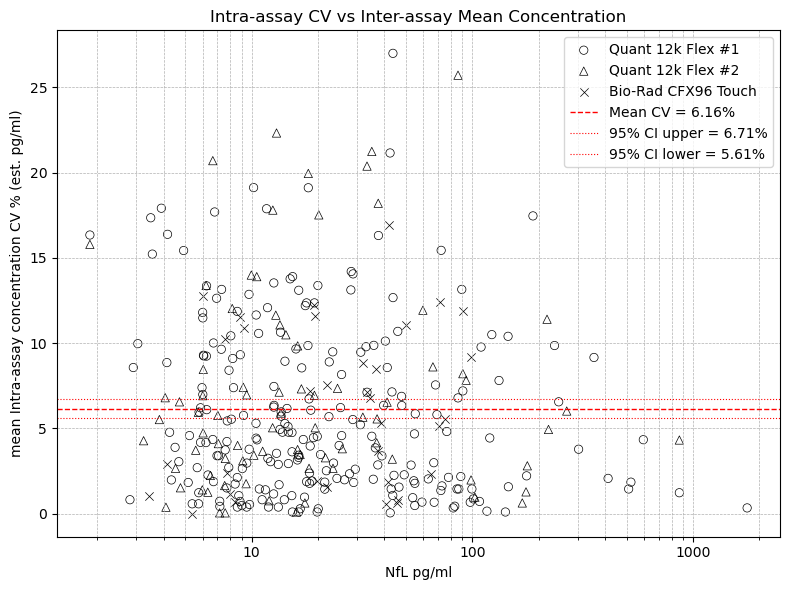

In [10]:
# Extract y values (CVs)
y = expanded_df['intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv']
x = expanded_df['inter-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L)']

# Drop NaNs for mean and SE calculation
y_clean = y.dropna()
mean_cv = np.mean(y_clean)
se_cv = stats.sem(y_clean)
ci_range = 1.96 * se_cv
ci_lower = mean_cv - ci_range
ci_upper = mean_cv + ci_range

# Marker logic based on 'Instrument tested'
instrument_col = expanded_df['Instrument'].astype(str)

is_285881442 = instrument_col == '285881442'
is_285882507 = instrument_col == '285882507'
is_biorad = instrument_col == '99'

# Plot
plt.figure(figsize=(8, 6))

# Open circles for 285881442
plt.scatter(
    x[is_285881442],
    y[is_285881442],
    marker='o',
    facecolors='none',
    edgecolors='black',
    linewidths=0.5,
    label='Quant 12k Flex #1'
)

# Open triangles for 285882507
plt.scatter(
    x[is_285882507],
    y[is_285882507],
    marker='^',
    facecolors='none',
    edgecolors='black',
    linewidths=0.5,
    label='Quant 12k Flex #2'
)

# 'x' markers for multi-instrument tests
plt.scatter(
    x[is_biorad],
    y[is_biorad],
    marker='x',
    color='black',
    linewidths=0.5,
    label='Bio-Rad CFX96 Touch'
)

# Mean and CI lines with labels
plt.axhline(mean_cv, color='red', linestyle='--', linewidth=1, label=f'Mean CV = {mean_cv:.2f}%')
plt.axhline(ci_upper, color='red', linestyle='dotted', linewidth=0.8, label=f'95% CI upper = {ci_upper:.2f}%')
plt.axhline(ci_lower, color='red', linestyle='dotted', linewidth=0.8, label=f'95% CI lower = {ci_lower:.2f}%')

# Set log scale and linear-looking x-axis tick labels
plt.xscale('log')
plt.gca().xaxis.set_major_formatter(ScalarFormatter())
plt.gca().ticklabel_format(style='plain', axis='x')

# Labels and title
plt.xlabel('NfL pg/ml')
plt.ylabel('mean Intra-assay concentration CV % (est. pg/ml)')
plt.title('Intra-assay CV vs Inter-assay Mean Concentration')

# Grid and legend
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()

# Save
# plt.savefig("nfl_intra_cv_plot.svg", dpi=300, bbox_inches='tight')
plt.show()



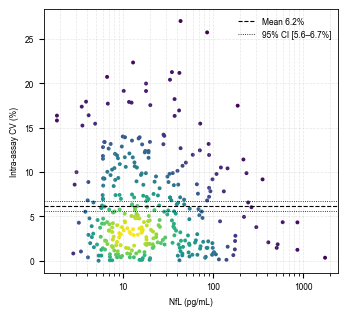

In [11]:
# ── Imports & rcParams ─────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde
from matplotlib.ticker import ScalarFormatter

plt.rcParams.update({
    'font.family':        'sans-serif',
    'font.sans-serif':    ['Helvetica', 'Arial'],
    'font.size':          6,
    'axes.titlesize':     6,
    'axes.labelsize':     6,
    'xtick.labelsize':    6,
    'ytick.labelsize':    6,
    'legend.fontsize':    6,
    'scatter.edgecolors': 'none',
    'axes.linewidth':     0.6,
})

# ── Data ───────────────────────────────────────────────────────────────────
cv_col   = 'intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv'
conc_col = 'inter-assay_mean (SLR; log10(x); exc_std0; ct; raw_ng/L)'

plot_df = expanded_df[[conc_col, cv_col]].dropna()
x_clean = plot_df[conc_col]
y_clean = plot_df[cv_col]

# ── Stats ──────────────────────────────────────────────────────────────────
mean_cv = np.mean(y_clean)
ci_range = 1.96 * stats.sem(y_clean)
ci_lower, ci_upper = mean_cv - ci_range, mean_cv + ci_range

# ── KDE density in log-x space ─────────────────────────────────────────────
xy      = np.vstack([np.log10(x_clean), y_clean])
kde     = gaussian_kde(xy)
density = kde(xy)

sort_idx = density.argsort()
x_sorted = x_clean.iloc[sort_idx]
y_sorted = y_clean.iloc[sort_idx]
d_sorted = density[sort_idx]

# ── Figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(88/25.4, 80/25.4))

ax.scatter(x_sorted, y_sorted, c=d_sorted, cmap='viridis', s=8)

ax.axhline(mean_cv,  color='black', linestyle='--',     linewidth=0.8, label=f'Mean {mean_cv:.1f}%')
ax.axhline(ci_upper, color='black', linestyle='dotted', linewidth=0.6, label=f'95% CI [{ci_lower:.1f}–{ci_upper:.1f}%]')
ax.axhline(ci_lower, color='black', linestyle='dotted', linewidth=0.6)

ax.set_xscale('log')
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

ax.set_xlabel('NfL (pg/mL)')
ax.set_ylabel('Intra-assay CV (%)')
ax.grid(True, which='both', linestyle='--', alpha=0.3, linewidth=0.5)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('fig_cv_profile.svg', dpi=300, bbox_inches='tight')
plt.show()

### Per-instrument summary statistics


In [12]:
# ── Per-instrument CV summary (Supplementary Table) ────────────────────────
cv_col = 'intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L) mean_cv'

instrument_labels = {
    '285881442': 'Quant 12k Flex #1',
    '285882507': 'Quant 12k Flex #2',
    '99':        'Bio-Rad CFX96 Touch',
}

rows = []
for serial, label in instrument_labels.items():
    vals = expanded_df.loc[expanded_df['Instrument'] == serial, cv_col].dropna()
    rows.append({
        'Instrument':  label,
        'n':           len(vals),
        'Mean CV (%)': round(vals.mean(), 1),
#         'SD':          round(vals.std(ddof=1), 1),
#         'Median CV (%)': round(vals.median(), 1),
        'IQR':         f"{round(vals.quantile(0.25), 1)}–{round(vals.quantile(0.75), 1)}",
    })

supp_table = pd.DataFrame(rows)
supp_table.to_csv("perInstrumentCV.csv")
supp_table


,Instrument,n,Mean CV (%),IQR
0,Quant 12k Flex #1,236,5.8,1.8–9.2
1,Quant 12k Flex #2,80,7.1,3.0–8.9
2,Bio-Rad CFX96 Touch,34,6.3,1.9–10.7


In [13]:
# Calculate mean and std for each group
groups = {
    'Quant 12k Flex #1': y[is_285881442],
    'Quant 12k Flex #2': y[is_285882507],
    'Bio-Rad CFX96 Touch': y[is_biorad]
}

stats_summary = {}
for label, values in groups.items():
    mean_val = np.mean(values)
    std_val = np.std(values, ddof=1)  # sample std (use ddof=0 for population)
    n = len(values)
    stats_summary[label] = {
        'n': n,
        'mean': mean_val,
        'std': std_val
    }

# Print summary
for label, vals in stats_summary.items():
    print(f"{label}: n={vals['n']}, mean={vals['mean']:.2f}, std={vals['std']:.2f}")


Quant 12k Flex #1: n=238, mean=5.84, std=5.00
Quant 12k Flex #2: n=80, mean=7.07, std=6.02
Bio-Rad CFX96 Touch: n=34, mean=6.30, std=4.71


### Flag samples with CV > 20%

Count of individual CV values exceeding 20% across all experiments. Each semicolon-delimited value in the raw column is treated as a separate observation.

In [14]:
# Count the number of tests that >20% CV
col = 'intra-assay_cv (SLR; log10(x); exc_std0; ct; raw_ng/L)'

cv_values = (
    expanded_df[col]
    .dropna()
    .astype(str)
    .str.split(';')
    .explode()
    .str.strip()
    .replace('', np.nan)
    .dropna()
    .astype(float)
    .tolist()
)

# Convert to NumPy array for comparison
cv_array = np.array(cv_values)

# Show results
print('total values:', len(cv_array))
print('total values above 20:', (cv_array > 20).sum())


total values: 369
total values above 20: 11
